### Load Dataset and Initial Inspection

I am loading the `train.csv` dataset into a pandas DataFrame and then performing initial inspections using `.head()`, `.info()`, and `.describe()` to understand its structure and content.

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

# Inspect data
print(df.head())
print(df.info())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

### Data Characteristics Summary

Based on the initial inspection, here's a summary of the dataset's characteristics:

In [4]:
# Number of rows and columns
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

# Identify columns with missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("\nColumns with missing values and their counts:")
if not missing_values.empty:
    display(missing_values)
else:
    print("No columns with missing values.")

# Separate categorical and numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of rows: 891
Number of columns: 12

Columns with missing values and their counts:


,0
Age,177
Cabin,687
Embarked,2



Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


The Titanic dataset contains 891 training rows and 418 test rows, with a mix of numerical and categorical features. Several columns have missing values, notably `Age`, `Cabin`, and `Embarked`, with `Cabin` being largely incomplete. Numerical features include variables like `Age`, `Fare`, and `Pclass`, while categorical features include `Sex`, `Embarked`, and `Ticket`. The target variable `Survived` is present only in the training data. Overall, the dataset will require preprocessing, especially handling missing values and encoding categorical variables, before building a machine learning model.

**Continue with the Titanic dataset (or the same dataset you started with)**

In [8]:
# Fill missing 'Age' values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' values with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' column due to a high number of missing values (errors='ignore' prevents error if column is already dropped)
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

print("Missing values after handling:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Display a summary of the cleaned data to show updated info
print("\nUpdated DataFrame Info after handling missing values:")
df.info()

Missing values after handling:


,0



Updated DataFrame Info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### Handling Missing Values

Based on the initial inspection, the following columns have missing values:

*   **Age**: 177 missing values. Given that 'Age' is a numerical feature, filling these missing values with the median age is a common and robust approach. The median is less sensitive to outliers compared to the mean.
*   **Cabin**: 687 missing values. This constitutes a significant portion of the dataset (~77%). Due to the high number of missing values, the 'Cabin' column will be dropped as it is unlikely to provide much predictive power in its current state without extensive feature engineering.
*   **Embarked**: 2 missing values. Since 'Embarked' is a categorical feature with only a few missing values, filling them with the mode (most frequent value) is an appropriate strategy to retain these rows without introducing bias.

Detect outliers in at least one numerical column using a **boxplot**

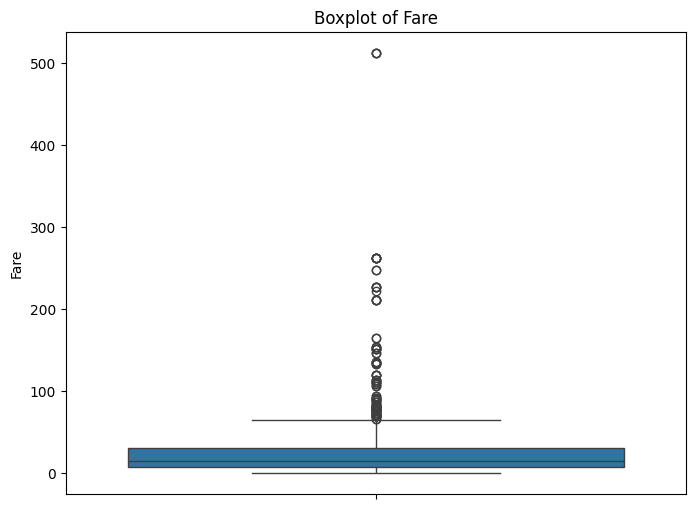

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for the 'Fare' column
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Fare'])
plt.title('Boxplot of Fare')
plt.ylabel('Fare')
plt.show()

### Outlier Detection for 'Fare' Column

The boxplot above visualizes the distribution of the 'Fare' column.

*   The box represents the interquartile range (IQR), with the median indicated by the line inside the box.
*   The 'whiskers' extend to the most extreme data points within 1.5 times the IQR from the box.
*   Any points beyond the whiskers are considered outliers. As seen in the plot, there are several data points with significantly higher fares, indicating potential outliers in the 'Fare' column.

Create at least 4 visualizations using matplotlib and seaborn: a histogram, a boxplot, a bar chart, and a correlation **heatmap**

### 1. Histogram: Distribution of Age

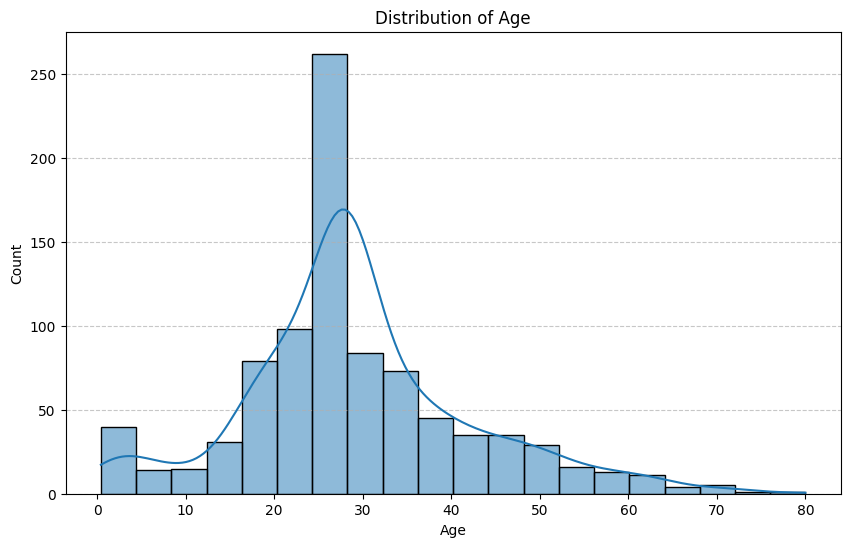

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Boxplot: Distribution of Age (for outlier detection)

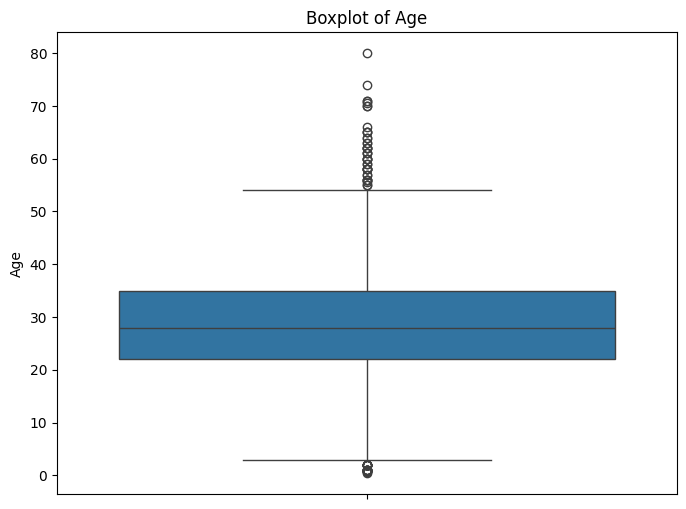

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

### 3. Bar Chart: Survival Count by Sex

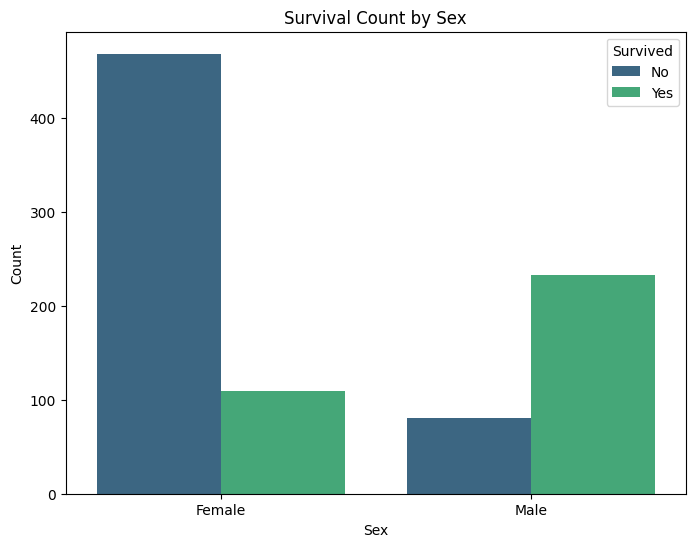

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 4. Correlation Heatmap of Numerical Features

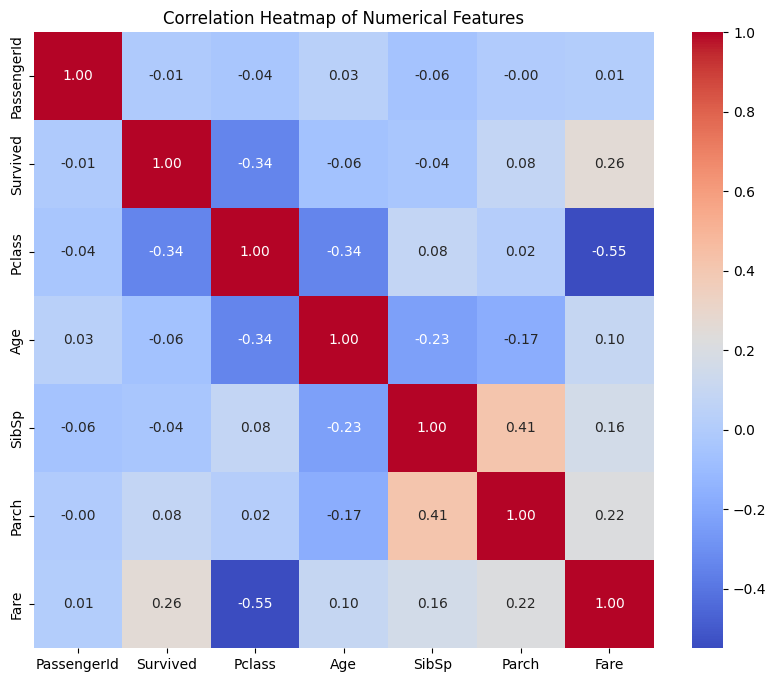

In [13]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Answer in writing: "Which feature do you think most affects survival, and why?

Based on the visualizations, Sex appears to be the feature that most affects survival. The bar chart clearly shows a much higher survival rate for females compared to males. While the correlation heatmap for numerical features indicates that 'Pclass' and 'Fare' also have some correlation with survival, the difference in survival rates based on 'Sex' is the most prominent visual distinction among the features analyzed.
